<img src="../img/htw-logo.png" width=150>


**I758 Wissens- und KI-basierte Systeme**

# Klassifikation mit kNN
Quelle: IBM Introduction to Machine Learning Specialization ([Yan Luo](https://www.linkedin.com/in/yan-luo-96288783/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML241ENSkillsNetwork31576874-2022-01-01))
 / Anpassungen CK
 

<font color="green"><b>KLAUSURTAUGLICH.</b></font>
Dieses Notebook gehört zu den fünf Notebooks, die Sie für die Klausur einreichen können. Bei vollständiger und korrekter Bearbeitung **erhalten Sie Punkte für die Abgabe, die zu Ihrer Klausur addiert werden.**

***

### Virtuelle Environments

**Hinweis:**:  In diesem Tutorial werden einige neue Bibliotheken wie z.B. die Visualisierungs-Bibliothek `seaborn` gebraucht. Mit ganz viel Glück sind diese Bibliotheken alle schon in Ihrem lokalen Environment installiert. Falls nicht, wird es Zeit, einmal die [Dokumentation von conda](https://docs.conda.io/projects/conda/en/latest/user-guide/tasks/manage-environments.html) zu studieren.

Legen Sie mit conda eine neue virtuelle Umgebung mit (zum Beispiel mit dem Namen `07-class` an. Installieren Sie in dieser Umgebung die folgenden Pakete:
   
```
   pip install -qy pandas==1.3.3 numpy==1.21.2 ipywidgets==7.4.2 scipy==7.4.2 tqdm==4.62.3 matplotlib==3.5.0 seaborn==0.9.0
```

Stellen Sie diese Umgebung in Ihrem Jupyter Notebook als Python-Compiler ein und arbeiten Sie erst dann mit diesem Notebook weiter!

***

In dieser Übung lernen Sie das K-Nearest-Neighbor-Modell (KNN) kennen und üben es. KNN ist ein unkompliziertes, aber sehr effektives Modell, das sowohl für Klassifizierungs- als auch für Regressionsaufgaben verwendet werden kann. Wenn der Merkmalsraum nicht sehr groß ist, kann KNN ein gut interpretierbares Modell sein, da Sie anhand der nächsten Nachbarn erklären und verstehen können, wie eine Vorhersage getroffen wird.

Wir werden einen Tumorprobendatensatz verwenden, der Labortestergebnisse zu Tumorproben enthält. Ziel ist die Klassifizierung, ob ein Tumor bösartig (Krebs) oder gutartig ist. Daher handelt es sich um eine typische binäre Klassifizierungsaufgabe.

### Ziele
Nach Abschluss dieser Übung sollten Sie folgende Fähigkeiten und Kenntnisse haben:
* Trainining von KNN-Modellen mit verschiedenen Nachbar-Hyperparametern
* Bewertung von Modellen für Klassifizierungsaufgaben
* Modell-Optiomierung durch Finden eines optimalen Hyperparameters

In [30]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics
# Evaluation metrics related methods
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix, precision_recall_fscore_support, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [31]:
# Define a random seed to reproduce any random process
rs = 123


In [32]:
# Ignore any deprecation warnings
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning) 
warnings.filterwarnings("ignore", category=FutureWarning) 


### Laden und untersuchen Sie den Tumorprobendatensatz

Wir laden zunächst den Datensatz „tumor.csv“ als Pandas-Dataframe:

In [33]:
# Read datast in csv format from online source
# dataset_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML241EN-SkillsNetwork/labs/datasets/tumor.csv"
## exactly the same file, but local:
dataset_url = "./data/tumor.csv"
tumor_df = pd.read_csv(dataset_url)


<span style="color:#FF5F00"><b>AUFGABE 1:</b></span><br>
Wie sieht der Tabellenkopf aus?

In [34]:
tumor_df.head()


,Clump,UnifSize,UnifShape,MargAdh,SingEpiSize,BareNuc,BlandChrom,NormNucl,Mit,Class
0,5,1,1,1,2,1,3,1,1,0
1,5,4,4,5,7,10,3,2,1,0
2,3,1,1,1,2,2,3,1,1,0
3,6,8,8,1,3,4,3,7,1,0
4,4,1,1,3,2,1,3,1,1,0


Was können wir über die Spalten erfahren?

In [35]:
tumor_df.columns


Index(['Clump', 'UnifSize', 'UnifShape', 'MargAdh', 'SingEpiSize', 'BareNuc',
       'BlandChrom', 'NormNucl', 'Mit', 'Class'],
      dtype='str')

In [36]:
tumor_df.describe()


,Clump,UnifSize,UnifShape,MargAdh,SingEpiSize,BareNuc,BlandChrom,NormNucl,Mit,Class
count,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000
mean,4.442167,3.150805,3.215227,2.830161,3.234261,3.544656,3.445095,2.869693,1.603221,0.349927
std,2.820761,3.065145,2.988581,2.864562,2.223085,3.643857,2.449697,3.052666,1.732674,0.477296
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,0.000000
50%,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000,0.000000
75%,6.000000,5.000000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,1.000000,1.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,1.000000


In [37]:
tumor_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 683 entries, 0 to 682
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Clump        683 non-null    int64
 1   UnifSize     683 non-null    int64
 2   UnifShape    683 non-null    int64
 3   MargAdh      683 non-null    int64
 4   SingEpiSize  683 non-null    int64
 5   BareNuc      683 non-null    int64
 6   BlandChrom   683 non-null    int64
 7   NormNucl     683 non-null    int64
 8   Mit          683 non-null    int64
 9   Class        683 non-null    int64
dtypes: int64(10)
memory usage: 53.5 KB


In [38]:
tumor_df.isnull().sum()


Clump          0
UnifSize       0
UnifShape      0
MargAdh        0
SingEpiSize    0
BareNuc        0
BlandChrom     0
NormNucl       0
Mit            0
Class          0
dtype: int64

In [39]:
tumor_df.shape


(683, 10)

<span style="color:green"><b>geben Sie nachfolgend Ihre schriftliche Antwort zur AUFGABE 1:</b></span><br>


Der Datensatz enthält 683 Zeilen mit 10 Spalten (`tumor_df.shape`). 

Die Spalten enthalten Messwerte zu Tumoren die zur Klassifikation von bös- bzw. gutartigen Tumoren dienen sollen. Sie geben Information über z.B. die Größe.

Eine kurze Recherche ergab, dass die Spalten folgendes bewerten:

- `Clump`: Größe bzw. Stärke der Zellklumpenbildung

- `UnifSize`: Gleichförmigkeit der Zellgröße

- `UnifShape`: Gleichförmigkeit der Zellform

- `MargAdh`: Randadhäsion, also wie stark Zellen aneinander haften

- `SingEpiSize`: Größe einzelner Epithelzellen

- `BareNuc`: Anteil bzw. Auffälligkeit nackter Zellkerne

- `BlandChrom`: Beschaffenheit des Chromatins im Zellkern

- `NormNucl`: Zustand bzw. Auffälligkeit normaler Nukleoli

- `Mit`: Mitosen, also Hinweise auf Zellteilungen

- `Class`: Zielvariable, also ob der Tumor gutartig (0) oder bösartig (1) ist

`tumor_df.describe()` zeigt, dass alle Spalten bis auf `"Class"` Werte von **1 bis 10** enthalten. `"Class"` enthält entweder **0 oder 1**.

`tumor_df.info()` und `tumor_df.isnull().sum()` zeigen, dass es keine `null`-Werte gibt und alle Spalten vom Typ `int64` sind.

Jede Beobachtung in diesem Datensatz enthält Labortestergebnisse zu einer Tumorprobe, beispielsweise Klumpen oder Formen. Basierend auf diesen Labortestergebnissen oder -merkmalen möchten wir ein Klassifizierungsmodell erstellen, um vorherzusagen, ob diese Tumorprobe bösartig (Krebs) oder gutartig ist. Die Zielvariable `y` wird in der Spalte `Class` angegeben.

Teilen wir die Daten in Input  `X` und Output `y` auf:


In [40]:
X = tumor_df.iloc[:, :-1]
y = tumor_df.iloc[:, -1:]


Wir schauen uns die Werte in `X` an:


In [41]:
X.describe()


,Clump,UnifSize,UnifShape,MargAdh,SingEpiSize,BareNuc,BlandChrom,NormNucl,Mit
count,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000
mean,4.442167,3.150805,3.215227,2.830161,3.234261,3.544656,3.445095,2.869693,1.603221
std,2.820761,3.065145,2.988581,2.864562,2.223085,3.643857,2.449697,3.052666,1.732674
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000
50%,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000
75%,6.000000,5.000000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,1.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


Wie wir der obigen Zellenausgabe entnehmen können, sind alle Merkmale numerisch und liegen im Bereich zwischen 1 und 10. Dies ist sehr praktisch, da wir die Merkmalswerte nicht skalieren müssen, da sie bereits im gleichen Bereich liegen.

<span style="color:#FF5F00"><b>AUFGABE 2:</b></span><br>

Erstellen Sie einen Bar Chart, der Ihnen anzeigt, wie viele Tumore gutartig sind (y = 0) und wieviele krankhaft (y = 1). 
</div>

Tipp: Pandas bietet Ihnen dafür die `value_counts` - Funktion. Für einen Dataframe `df` können Sie außerdem mit `df.plot.bar()` einen Barchart plotten. Sie sollten auf ungefähr 65% gutartige Tumore kommen. 


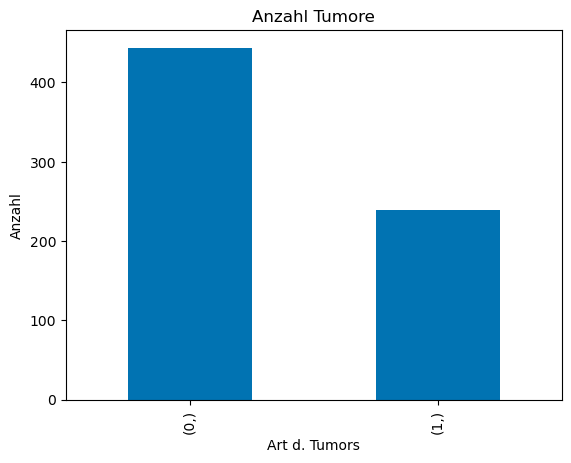

In [42]:
plot = y.value_counts().plot.bar()
plot.set_title("Anzahl Tumore")
plot.set_xlabel("Art d. Tumors")
plot.set_ylabel("Anzahl")
plt.show()


In [43]:
y.value_counts()


Class
0        444
1        239
Name: count, dtype: int64

In dem Diagramm sieht man, dass 444 Einträge gutartige Tumore enthalten (`"Class"` = 0) und 239 Einträge bösartige Tumore beschreiben (`"Class"` = 1).

Damit ergibt sich ein Verhältnis von:

`444 / (444 + 239) = 0.65 (gerundet)`

### Trainings- und Testdatensätze verarbeiten und aufteilen

In [44]:
# Split 80% as training dataset
# and 20% as testing dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state = rs)


### Trainieren und bewerten Sie einen KNN-Klassifikator mit K=2

Das Training eines KNN-Klassifikators ist dem Training anderer Klassifikatoren in „sklearn“ sehr ähnlich. Wir müssen zunächst ein `KNeighborsClassifier`-Objekt definieren. Hier verwenden wir das Argument `n_neighbors=2`, um anzugeben, wie viele Nachbarn für die Vorhersage verwendet werden, und behalten andere Argumente als Standardwerte bei.

In [45]:
# Define a KNN classifier with `n_neighbors=2`
knn_model = KNeighborsClassifier(n_neighbors=2)


Dann können wir das Modell mit `X_train` und `y_train` trainieren und verwenden die `ravel()`-Methode, um den Dataframe `y_train` in einen Vektor umzuwandeln.

In [46]:
knn_model.fit(X_train, y_train.values.ravel())


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",2
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


Wir machen Vorhersagen auf  `X_test`:


In [47]:
preds = knn_model.predict(X_test)


Um die Modellqualität im Detail zu verstehen, zeichnen wir eine Confusion Matrix:

Text(33.22222222222222, 0.5, 'Ground Truth')

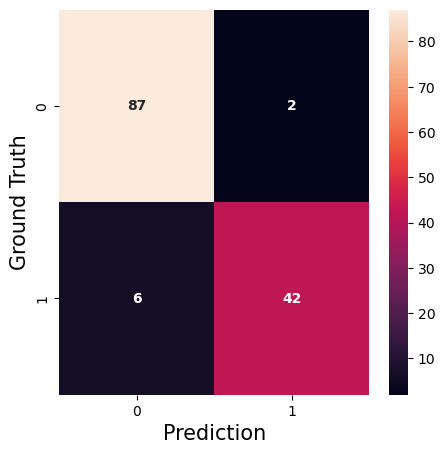

In [48]:
# Plot confusion matrix
sns.set_palette(sns.color_palette())
_, ax = plt.subplots(figsize=(5,5))
ax = sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt='d', annot_kws={"size": 10, "weight": "bold"})  

ax.set_xlabel('Prediction', fontsize=15);
ax.set_ylabel('Ground Truth', fontsize=15)


Um den KNN-Klassifikator auszuwerten, stellen wir eine vordefinierte Methode zur Verfügung, um die häufig verwendeten Bewertungsmetriken wie Genauigkeit, Rückruf, Präzision, f1score usw. basierend auf den wahren Klassen im `y_test` und den Modellvorhersagen zurückzugeben.

In [49]:
def evaluate_metrics(yt, yp):
    results_pos = {}
    results_pos['accuracy'] = round(accuracy_score(yt, yp), 3)
    precision, recall, f_beta, _ = precision_recall_fscore_support(yt, yp, average='binary')
    results_pos['recall'] = round(recall, 3)
    results_pos['precision'] = round(precision, 3)
    results_pos['f1score'] = round(f_beta, 3)
    return results_pos


In [50]:
evaluate_metrics(y_test, preds)


{'accuracy': 0.942, 'recall': 0.875, 'precision': 0.955, 'f1score': 0.913}

<span style="color:#FF5F00"><b>AUFGABE 3:</b></span><br>

Informieren Sie sich in der Dokumentation von SciKit Learn über die Definition dieser Metriken!  
Beschreiben Sie zusätzlich die Modellqualität anhand der Confusion Matrix.

<span style="color:green"><b>geben Sie nachfolgend Ihre schriftliche Antwort zur AUFGABE 3:</b></span><br>

`accuracy` - Wie genau ist das Modell in sowohl positiven als auch negativen Vorhersagen?<br>
`recall` - Wie viele tatsächlich bösartige Tumore wurden erkannt?<br>
`precision` - Wie viele als bösartig bezeichnete Tumore waren es auch?<br>
`f1score` - Harmonisches Mittel aus Recall und Precision, wobei beide gleich gewichtet sind.<br>

### Analyse der Confusion-Matrix (CM)

> **Hinweis**: Ich glaube die Beschriftungen der Achsen ("Ground Truth" und "Prediction") waren vertauscht. Ich habe die Achsen entsprechend geändert. In [[diesem Tutorial](https://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html)] sind die Vorhergesagten Werte auf der x-Achse, nicht wie bei uns auf der y-Achse.<br>
> Könnten Sie das nochmal überprüfen? Ich habe für die Analyse angenommen, dass die gegebenen Beschriftungen *falsch* sind und mich an dem Beispiel online orientiert. So ergeben die Werte für recall etc. auch Sinn.

Die CM zeigt, dass das Modell sehr viele richtige Aussagen trifft (Tn: 87, Tp: 42). Eine sehr geringe Anzahl an **False Positives** (Fp: 2) und **False Negatives** (Fn: 6) zeigen, dass das Modell sehr akkurate Aussagen trifft, aber bösartige Tumore öfter falsch gelabelt werden als gutartige, was aus medizinischer Sicht natürlich höchst problematisch ist.

Grundsätzlich schätzt das Modell außerdem öfter "gutartig" (`"Class"` = 0, n: 87 + 6 = **93**) als "bösartig" (`"Class"` = 1, n: 2 + 42 = **44**), was bei einer höheren Anzahl an gutartigen Tumoren im Datensatz aber zu erwarten ist.

Wir können sehen, dass der Tumorprobendatensatz eine hervorragende Klassifizierungsleistung aufweist. Dies bedeutet, dass das KNN-Modell Krebstumoren effektiv erkennen kann. Als nächstes sind Sie an der Reihe, eine andere Anzahl von Nachbarn auszuprobieren, um zu sehen, ob wir eine noch bessere Leistung erzielen könnten.

### Verbessern Sie das Modell

<span style="color:#FF5F00"><b>AUFGABE 4:</b></span><br>

Verbessern Sie das Modell, indem Sie einen weiteren kNN-Classifier trainieren, diesmal jedoch mit k=5.
</div>
Geben Sie eine Einschätzung zur Evaluierung des Modells ab.

Definieren Sie zunächst einen KNN-Klassifikator mit der Klasse KNeighborsClassifier:

In [51]:
# Type your code here
knc = KNeighborsClassifier(n_neighbors=5)


Jetzt trainieren Sie das Modell mit  `X_train` und `y_train`:


In [52]:
# Type your code here
knc.fit(X_train, y_train)


/Users/feli/anaconda3/envs/wikisys/lib/python3.14/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


Machen Sie Vorhersagen auf  `X_test` und evaluieren Sie mit  `evaluate_metrics()` auf `y_test` und `preds`:


In [53]:
# Type your code here
preds = knc.predict(X_test)

evaluate_metrics(y_test, preds)


{'accuracy': 0.978, 'recall': 0.979, 'precision': 0.959, 'f1score': 0.969}

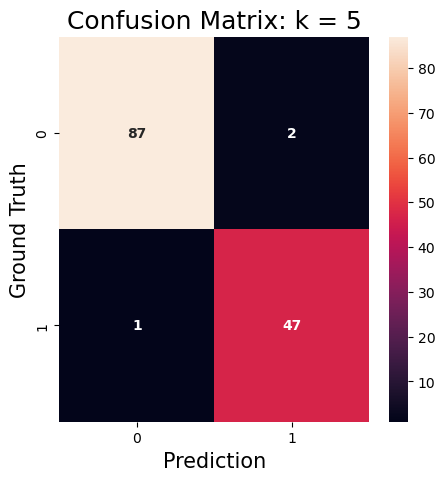

In [54]:
# Plot confusion matrix
sns.set_palette(sns.color_palette("colorblind"))
_, ax = plt.subplots(figsize=(5,5))
ax = sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt='d', annot_kws={"size": 10, "weight": "bold"})  
ax.set_title("Confusion Matrix: k = 5", fontsize=18)
ax.set_xlabel('Prediction', fontsize=15);
ax.set_ylabel('Ground Truth', fontsize=15)
plt.show()


<span style="color:green"><b>geben Sie nachfolgend Ihre schriftliche Antwort zur AUFGABE 4:</b></span><br>

### Kennwerte mit `evaluate_metrics()`

| Metrik | Neu | Delta | Vorher |
|---|---:|---:|---:|
| `accuracy` | 0.978 | +0.036 | 0.942 |
| `recall` | 0.979 | +0.104 | 0.875 |
| `precision` | 0.959 | +0.004 | 0.955 |
| `f1score` | 0.969 | +0.056 | 0.913 |

Alle Werte haben sich etwas verbessert! Insbesondere der Recall (= Anteil bösartige Tumore, die richtig erkannt wurden) ist deutlich besser geworden. Das lässt vermuten, dass das Modell durch das Erhöhen von `k` auf 5 besser im Vorhersagen von positiven Werten geworden ist.

### Confusion Matrix

Auch die Matrix hat sich verbessert. Diesmal wurden **5 der ursprünglich 6 False Negatives** korrekt als "bösartig" vorhergesagt. Die **True Positives/Negatives** haben sich nicht verändert. Das Erhöhen der Nachbarzahl (`k`) hat sich bei diesem Datensatz nur auf die vorhergesagten positiven Werte ausgewirkt. Das deckt sich mit den Beobachtungen zu `accuracy`, `recall` (am meisten verbessert) und `precision`.

### Finden Sie das beste Modell

<span style="color:#FF5F00"><b>AUFGABE 5:</b></span><br>

Verbessern Sie das Modell noch weiter, indem Sie den besten Wert für K finden.
</div>

Hier könnten wir K von 1 bis 50 ausprobieren und den aggregierten `f1score` für jedes k in einer Liste speichern.

In [55]:
# Try K from 1 to 50
max_k = 50
# Create an empty list to store f1score for each k
f1_scores = []


Dann trainieren wir 50 KNN-Klassifikatoren mit K im Bereich von 1 bis 50.
Vervollständigen Sie den folgenden Code:

In [56]:
for k in range(1, max_k + 1):
    # Create a KNN classifier
    knn_clf = KNeighborsClassifier(n_neighbors=k)

    # Train the classifier
    knn_clf.fit(X_train, y_train.squeeze())

    # Predict
    preds = knn_clf.predict(X_test)

    # Evaluate
    f1 = float(f1_score(y_test, preds))
    f1_scores.append((k, round(f1, 4)))

# Convert to dataframe
f1_results = pd.DataFrame(f1_scores, columns=['K', 'F1 Score'])
f1_results = f1_results.set_index('K')
f1_results


,F1 Score
K,
1,0.9485
2,0.9130
3,0.9485
4,0.9583
5,0.9691
6,0.9583
7,0.9583
8,0.9474
9,0.9474


Dies ist eine lange Liste und unterscheidet sich von der Analyse. Lassen Sie uns die Liste also mithilfe eines Liniendiagramms visualisieren.

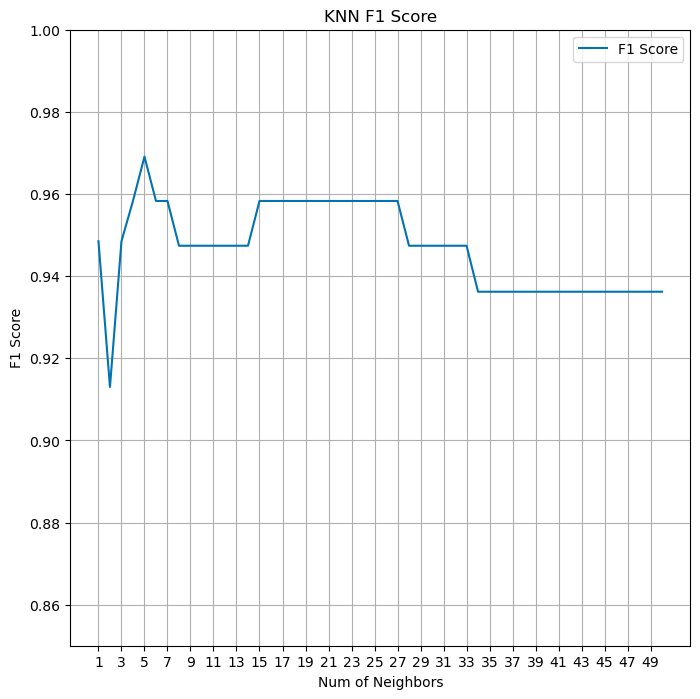

In [57]:
# Plot F1 results
ax = f1_results.plot(figsize=(8, 8))
ax.set(xlabel='Num of Neighbors', ylabel='F1 Score')
ax.set_xticks(range(1, max_k, 2));
plt.ylim((0.85, 1))
plt.grid(visible=True)
plt.title('KNN F1 Score')
plt.show()


<span style="color:#FF5F00"><b>AUFGABE 6:</b></span><br>
Welches K ist das beste? Welchen F1-Score können Sie damit erreichen?
</div>

<span style="color:green"><b>geben Sie nachfolgend Ihre schriftliche Antwort zur AUFGABE 6:</b></span><br>

In [58]:
# Eintrag mit größtem F1-Score finden
# k wird als Index gespeichert --> einfach extrahierbar
best_k = f1_results["F1 Score"].idxmax()
f1_results.loc[best_k]


F1 Score    0.9691
Name: 5, dtype: float64

Es stellt sich raus, dass **5** bereits die beste Wahl für `k` ist. Damit wird auf den Testdaten ein F1-Score von ca. 0.969 erreicht.

Es ist außerdem zu beachten, dass `k = 2` besonders schlecht abgeschnitten hat, was vermutlich daran liegt, dass bei einer geringen geraden Anzahl an Nachbarn die "Falsche" Klasse zu viel Einfluss auf die Vorhersage hat.

<span style="color:#FF5F00"><b>AUFGABE 7:</b></span><br>
Welchen Effekt hat der Parameter K? Wovon ist der Parameter K abhängig?
</div>

<span style="color:green"><b>geben Sie nachfolgend Ihre schriftliche Antwort zur AUFGABE 7:</b></span><br>

`k` steuert die Anzahl an Nachbarn, die für die Klassifikation eines Datenpunktes betrachtet werden. 

Je *geringer* `k`ist, desto empfindlicher wird die Vorhersage gegenüber Rauschen oder Ausreißern. Wählt man `k`zu *groß*, verschwimmen die Grenzen zwischen den Klassen aber mehr, wodurch die Vorhersage "verwässert" werden kann.

`k` muss also so gewählt werden, dass möglichst viele Nachbarn der gleichen Klasse und gleichzeitig möglichst wenig Ausreißer und Nachbarn anderer Klassen betrachtet werden.<br>
Es ist also von der Dichte, Verteilung und Anzahl der Punkte und Klassen abhängig. Auch wichtig ist der Grad der Überlappung der einzelnen Klassen und die Menge an Rauschen. Je weiter die einzelnen Klassen auseinander liegen, desto vorteilhafter ist es, `k` etwas größer zu wählen, da der Großteil der nahen Nachbarn so zur richtigen Klasse gehören und Ausreißer weniger Einfluss haben.
 